# 株価データ分析 with yfinance
Git & GitHub の練習を兼ねた、yfinanceを使った簡単な株価分析ノートブックです。

## 1. 必要なライブラリのインポート

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 日本語フォントの設定（文字化け対策）
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['figure.figsize'] = (12, 5)

print("ライブラリの読み込み完了！")

ライブラリの読み込み完了！


## 2. 株価データの取得

- `7203.T` → トヨタ自動車（東証）
- 期間：過去1年分

In [2]:
# 銘柄コードと期間を指定してデータ取得
ticker = "7203.T"  # トヨタ自動車
df = yf.download(ticker, period="1y")  # 過去1年分

print(f"取得した銘柄：{ticker}")
print(f"データ件数：{len(df)} 日分")
df.head()

[*********************100%***********************]  1 of 1 completed

取得した銘柄：7203.T
データ件数：245 日分


Price,Close,High,Low,Open,Volume
Ticker,7203.T,7203.T,7203.T,7203.T,7203.T
Date,,,,,
2025-03-11,2664.804199,2688.990115,2624.655579,2680.283185,32542100
2025-03-12,2671.576416,2675.929881,2641.102160,2660.450894,23961100
2025-03-13,2630.460205,2673.994854,2630.460205,2670.125107,26657300
2025-03-14,2657.064697,2692.859852,2633.846218,2633.846218,32732200
2025-03-17,2670.608887,2701.083141,2660.450802,2660.450802,20673100


## 3. データの確認と前処理

In [9]:
df

Price,Close,High,Low,Open,Volume,MA25,MA75,Daily_Return
Ticker,7203.T,7203.T,7203.T,7203.T,7203.T,,,
Date,,,,,,,,
2025-03-11,2664.804199,2688.990115,2624.655579,2680.283185,32542100,NaN,NaN,NaN
2025-03-12,2671.576416,2675.929881,2641.102160,2660.450894,23961100,NaN,NaN,0.254136
2025-03-13,2630.460205,2673.994854,2630.460205,2670.125107,26657300,NaN,NaN,-1.539024
2025-03-14,2657.064697,2692.859852,2633.846218,2633.846218,32732200,NaN,NaN,1.011401
2025-03-17,2670.608887,2701.083141,2660.450802,2660.450802,20673100,NaN,NaN,0.509743
...,...,...,...,...,...,...,...,...
2026-03-05,3481.000000,3635.000000,3481.000000,3600.000000,31699400,3668.12,3424.400000,-1.107955
2026-03-06,3515.000000,3543.000000,3470.000000,3490.000000,20575900,3674.84,3428.733333,0.976731


In [3]:
# データの末尾を確認
print("▼ 末尾5行")
print(df.tail())

# 欠損値の確認
print("\n▼ 欠損値の数")
print(df.isnull().sum())

# データ型の確認
print("\n▼ データ型")
print(df.dtypes)

▼ 末尾5行
Price        Close    High     Low    Open    Volume
Ticker      7203.T  7203.T  7203.T  7203.T    7203.T
Date                                                
2026-03-05  3481.0  3635.0  3481.0  3600.0  31699400
2026-03-06  3515.0  3543.0  3470.0  3490.0  20575900
2026-03-09  3393.0  3423.0  3295.0  3299.0  28223800
2026-03-10  3473.0  3517.0  3432.0  3463.0  22222100
2026-03-11  3538.0  3553.0  3500.0  3501.0   3987000

▼ 欠損値の数
Price   Ticker
Close   7203.T    0
High    7203.T    0
Low     7203.T    0
Open    7203.T    0
Volume  7203.T    0
dtype: int64

▼ データ型
Price   Ticker
Close   7203.T    float64
High    7203.T    float64
Low     7203.T    float64
Open    7203.T    float64
Volume  7203.T      int64
dtype: object


## 4. 基本統計量の算出

In [4]:
# 終値（Close）の基本統計量
df[["Close"]].describe().round(1)

Price,Close
Ticker,7203.T
count,245.0
mean,2945.9
std,401.2
min,2232.2
25%,2630.5
50%,2861.0
75%,3185.0
max,3944.0


## 5. 株価の可視化（終値）

In [ ]:
"""
fig  # 図全体（額縁）
ax   # グラフの描画エリア（キャンバス）

ax.xaxis                          # ax のX軸
  .set_major_formatter(           # 目盛りのフォーマットを設定する
    mdates.DateFormatter("%Y-%m") # 日付を「2025-01」形式で表示
  )
"""

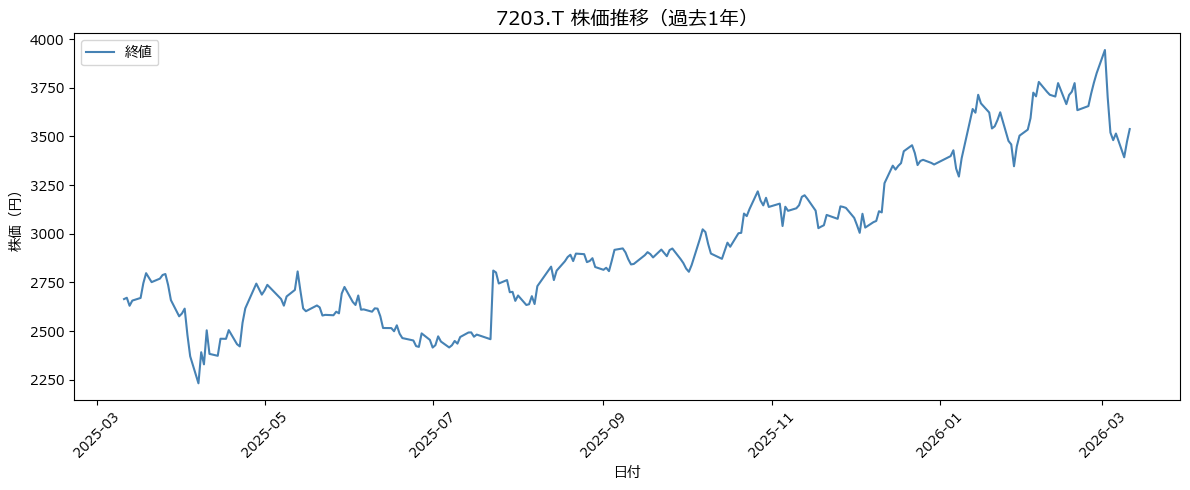

In [5]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], color="steelblue", linewidth=1.5, label="終値")
ax.set_title(f"{ticker} 株価推移（過去1年）", fontsize=14)
ax.set_xlabel("日付")
ax.set_ylabel("株価（円）")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. 移動平均の計算と描画

In [13]:
""""
df["Close"]           # df という表の "Close" 列を取り出す
         .rolling(    # その列に対して「窓（ウィンドウ）」を設定する
           window=25  # 窓のサイズ = 25行分
         )
"""

'"\ndf["Close"]           # df という表の "Close" 列を取り出す\n         .rolling(    # その列に対して「窓（ウィンドウ）」を設定する\n           window=25  # 窓のサイズ = 25行分\n         )\n'

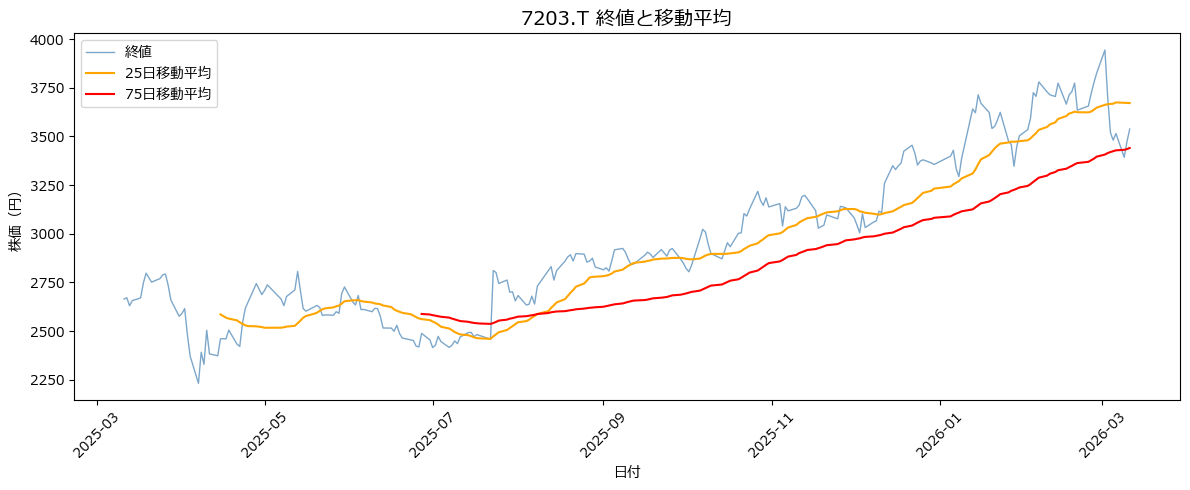

In [6]:
# 移動平均を計算
df["MA25"] = df["Close"].rolling(window=25).mean()   # 25日移動平均
df["MA75"] = df["Close"].rolling(window=75).mean()   # 75日移動平均

fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], color="steelblue",  linewidth=1,   label="終値",       alpha=0.7)
ax.plot(df.index, df["MA25"],  color="orange",     linewidth=1.5, label="25日移動平均")
ax.plot(df.index, df["MA75"],  color="red",        linewidth=1.5, label="75日移動平均")
ax.set_title(f"{ticker} 終値と移動平均", fontsize=14)
ax.set_xlabel("日付")
ax.set_ylabel("株価（円）")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. 日次リターンの分析

In [ ]:
"""
df["Daily_Return"]   # Daily_Return 列を取り出す
  .dropna()          # NaN（空欄）の行を除外する
"""

''

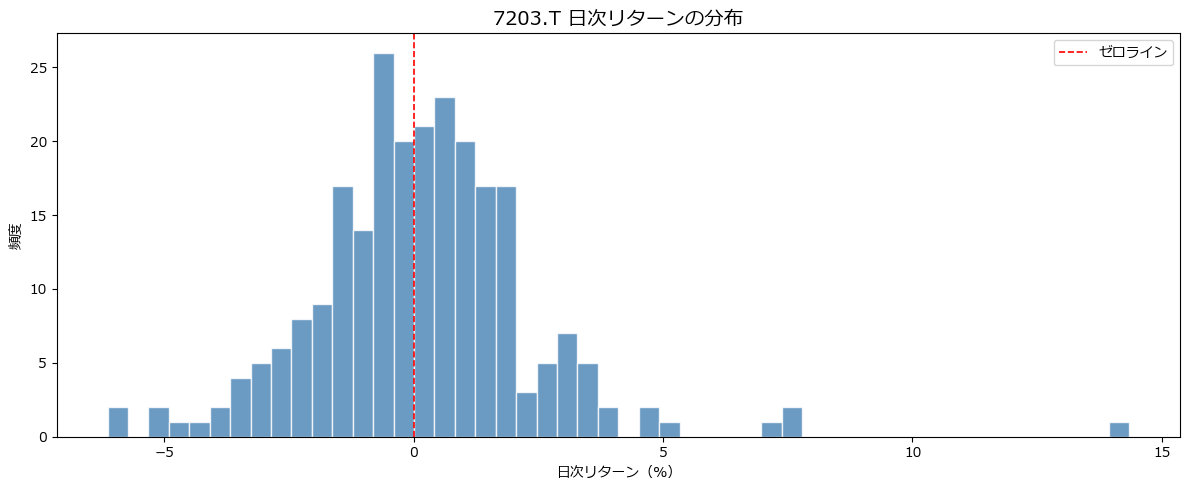

平均リターン：0.141%
標準偏差　　：2.250%


In [7]:
# 日次リターン（前日比の変化率）を計算
df["Daily_Return"] = df["Close"].pct_change() * 100  # %表示

fig, ax = plt.subplots()
ax.hist(df["Daily_Return"].dropna(), bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="ゼロライン")
ax.set_title(f"{ticker} 日次リターンの分布", fontsize=14)
ax.set_xlabel("日次リターン（%）")
ax.set_ylabel("頻度")
ax.legend()
plt.tight_layout()
plt.show()

print(f"平均リターン：{df['Daily_Return'].mean():.3f}%")
print(f"標準偏差　　：{df['Daily_Return'].std():.3f}%")

## 8. 複数銘柄の相関分析

複数の日本株を比較してみましょう。

In [ ]:
"""
sns.heatmap(corr,
  annot=True,   # 各セルに数値を表示する（True/False）
  fmt=".2f",    # 数値のフォーマット（小数点2桁）
)
"""

''

[*********************100%***********************]  5 of 5 completed


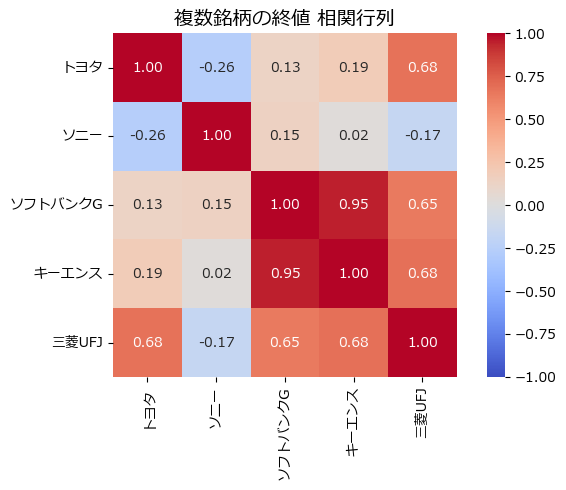

In [8]:
# 複数銘柄の終値を一括取得
tickers = {
    "7203.T": "トヨタ",
    "6758.T": "ソニー",
    "9984.T": "ソフトバンクG",
    "6861.T": "キーエンス",
    "8306.T": "三菱UFJ",
}

prices = yf.download(list(tickers.keys()), period="1y")["Close"]
prices.columns = list(tickers.values())  # 列名を日本語に変更

# 相関行列を計算
corr = prices.corr()

# ヒートマップで可視化
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("複数銘柄の終値 相関行列", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
prices

,トヨタ,ソニー,ソフトバンクG,キーエンス,三菱UFJ
Date,,,,,
2025-03-11,3370.238770,60171.617188,2664.804199,1831.936646,1953.588013
2025-03-12,3491.563232,60112.078125,2671.576416,1867.743164,1937.650513
2025-03-13,3469.685059,59665.554688,2630.460205,1893.872192,1931.424927
2025-03-14,3498.524414,60925.742188,2657.064697,1935.968994,1951.346924
2025-03-17,3569.131592,60598.292969,2670.608887,1964.517334,1986.957153
...,...,...,...,...,...
2026-03-05,3380.000000,61310.000000,3481.000000,2735.000000,3864.000000
2026-03-06,3473.000000,61750.000000,3515.000000,2759.500000,3926.000000
2026-03-09,3346.000000,57870.000000,3393.000000,2665.000000,3541.000000


In [ ]:
yf.download(list(tickers.keys()), period="1y")

[*********************100%***********************]  5 of 5 completed


Price             Close                                                       \
Ticker           6758.T        6861.T       7203.T       8306.T       9984.T   
Date                                                                           
2025-03-11  3370.238770  60171.617188  2664.804199  1831.936646  1953.588013   
2025-03-12  3491.563232  60112.078125  2671.576172  1867.743164  1937.650513   
2025-03-13  3469.685059  59665.554688  2630.460205  1893.872192  1931.424927   
2025-03-14  3498.524414  60925.742188  2657.064697  1935.968994  1951.346924   
2025-03-17  3569.131592  60598.292969  2670.608887  1964.517334  1986.957153   
...                 ...           ...          ...          ...          ...   
2026-03-05  3380.000000  61310.000000  3481.000000  2735.000000  3864.000000   
2026-03-06  3473.000000  61750.000000  3515.000000  2759.500000  3926.000000   
2026-03-09  3346.000000  57870.000000  3393.000000  2665.000000  3541.000000   
2026-03-10  3403.000000  60650.000000  3473.000000  2721.500000  3632.000000   
2026-03-11  3441.000000  61520.000000  3536.000000  2750.500000  3941.000000   

Price              High                                                       \
Ticker           6758.T        6861.T       7203.T       8306.T       9984.T   
Date                                                                           
2025-03-11  3388.139123  60280.767548  2688.990115  1834.839873  1953.588013   
2025-03-12  3544.269826  60796.748543  2675.929637  1879.839946  1959.564566   
2025-03-13  3562.170215  61005.127261  2673.994854  1904.517361  1993.929782   
2025-03-14  3542.280831  60965.433225  2692.859852  1941.775450  1963.300044   
2025-03-17  3598.965514  61273.040623  2701.083141  1973.710888  2005.882926   
...                 ...           ...          ...          ...          ...   
2026-03-05  3463.000000  62720.000000  3635.000000  2788.000000  4037.000000   
2026-03-06  3490.000000  62110.000000  3543.000000  2759.500000  3953.000000   
2026-03-09  3346.000000  59600.000000  3423.000000  2676.500000  3598.000000   
2026-03-10  3443.000000  60650.000000  3517.000000  2753.000000  3687.000000   
2026-03-11  3477.000000  61900.000000  3553.000000  2763.000000  3966.000000   

Price       ...         Open                                          \
Ticker      ...       6758.T        6861.T       7203.T       8306.T   
Date        ...                                                        
2025-03-11  ...  3291.676107  59983.084746  2680.283185  1819.355992   
2025-03-12  ...  3410.017181  60707.443706  2660.450651  1840.646372   
2025-03-13  ...  3539.297542  60677.676187  2670.125107  1889.033480   
2025-03-14  ...  3462.723709  59735.011070  2633.846218  1906.452846   
2025-03-17  ...  3578.081769  61144.044748  2660.450802  1954.839909   
...         ...          ...           ...          ...          ...   
2026-03-05  ...  3459.000000  62260.000000  3600.000000  2745.000000   
2026-03-06  ...  3358.000000  61190.000000  3490.000000  2696.000000   
2026-03-09  ...  3220.000000  58970.000000  3299.000000  2579.000000   
2026-03-10  ...  3398.000000  59100.000000  3463.000000  2715.000000   
2026-03-11  ...  3455.000000  61350.000000  3501.000000  2738.000000   

Price                      Volume                                         
Ticker           9984.T    6758.T   6861.T    7203.T    8306.T    9984.T  
Date                                                                      
2025-03-11  1919.969863  21476800   625600  32542100  73519900  40330000  
2025-03-12  1952.342889  20545800   406000  23961100  52283100  25502400  
2025-03-13  1975.004009  14738300   605200  26657300  46852300  32905600  
2025-03-14  1894.071555  16920900   660100  32732200  68846600  41186000  
2025-03-17  1987.206177  12693700   455000  20673100  51530100  23522000  
...                 ...       ...      ...       ...       ...       ...  
2026-03-05  3900.000000  25755800  1009300  31699400  56480400  45759900  